# Chapter Summary

Evaluating machine learning models is essential for understanding how well they will perform on unseen data.

Cross-validation is a statistical technique that helps estimate model performance by repeatedly splitting data into training and validation sets. It reduces the risk of overfitting and provides a more reliable assessment of model generalization.

This chapter introduces cross-validation strategies, model selection techniques, hyperparameter tuning, and methods for evaluating machine learning models using scikit-learn.

# Learning Objectives

After completing this chapter, students should be able to:

- Understand cross-validation concepts.
- Apply different cross-validation techniques.
- Use scikit-learn cross-validation tools.
- Perform model selection.
- Evaluate model generalization.
- Tune hyperparameters effectively.

## Introduction to Cross-Validation

Cross-validation is used to estimate how well a machine learning model will perform on unseen data.

Instead of evaluating a model using a single train-test split, cross-validation repeatedly partitions the dataset and computes performance across multiple folds.

Benefits include:

- More reliable evaluation.
- Reduced variance.
- Better model selection.
- Improved generalization assessment.

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)

(150, 4)


## Basic K-Fold Cross-Validation

K-Fold Cross-Validation divides data into K subsets.

The model is trained K times:

- One fold is used for validation.
- Remaining folds are used for training.

The final score is the average across all folds.

In [2]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [3]:
print("Mean Accuracy:", scores.mean())

Mean Accuracy: 0.9733333333333334


Cross-validation provides multiple evaluation results instead of relying on a single train-test split, producing a more reliable estimate of model performance.

## Advanced Cross-Validation Methods

Scikit-learn provides several advanced validation strategies:

- Stratified K-Fold
- Leave-One-Out
- Repeated K-Fold
- Shuffle Split

Different strategies are suitable for different datasets and modeling scenarios.

In [4]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=skf
)

print(scores)

[1.         0.96666667 0.93333333 1.         0.93333333]


Stratified K-Fold preserves class distribution across folds, making it particularly useful for classification tasks.

## Implementing Cross-Validation in scikit-learn

Scikit-learn provides several convenient tools for implementing cross-validation.

The most common functions include:

- cross_val_score()
- cross_validate()
- GridSearchCV()

In [5]:
from sklearn.model_selection import cross_validate

results = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring=["accuracy"]
)

print(results)

{'fit_time': array([0.02075481, 0.02792883, 0.02262878, 0.02680016, 0.03280544]), 'score_time': array([0.00096369, 0.00102282, 0.00099683, 0.00099969, 0.00099397]), 'test_accuracy': array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])}


## Model Selection Techniques

Model selection involves comparing different algorithms and selecting the model that performs best on validation data.

Common approaches include:

- Cross-validation
- Grid Search
- Randomized Search
- Validation Curves

In [6]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    parameters,
    cv=5
)

grid_search.fit(X, y)

print(grid_search.best_params_)

{'C': 1}


In [7]:
print(grid_search.best_score_)

0.9733333333333334


## Evaluating Model Generalizability

Generalization refers to a model's ability to perform well on unseen data.

A model that performs well on training data but poorly on new data is considered overfitted.

Cross-validation helps estimate generalization performance before deployment.

In [8]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5
)

print(train_sizes)

[ 12  39  66  93 120]


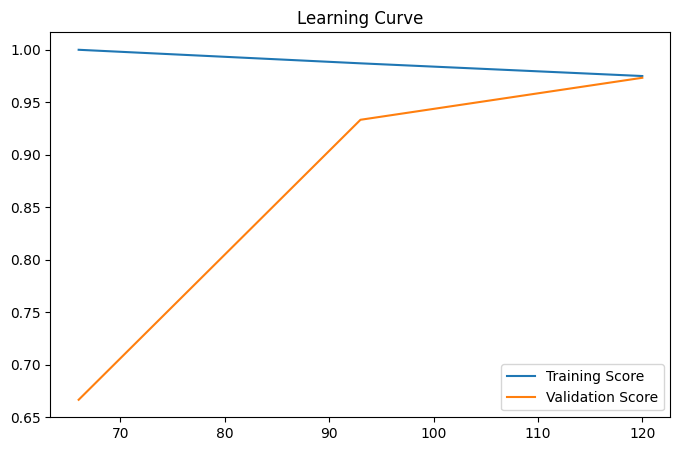

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    label="Training Score"
)

plt.plot(
    train_sizes,
    np.mean(test_scores, axis=1),
    label="Validation Score"
)

plt.legend()

plt.title("Learning Curve")

plt.show()

In [10]:
exercise_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=10
)

print(exercise_scores)

[1.         0.93333333 1.         1.         0.93333333 0.93333333
 0.93333333 1.         1.         1.        ]


In [11]:
exercise_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {"C":[0.01,0.1,1,10]},
    cv=5
)

exercise_grid.fit(X, y)

print(exercise_grid.best_params_)

{'C': 1}


In [12]:
print(
    "Average Validation Score:",
    np.mean(test_scores)
)

Average Validation Score: nan


# Discussion

This chapter explored cross-validation techniques and model evaluation methods.

Several validation strategies were implemented, including K-Fold Cross-Validation and Stratified K-Fold. Model selection was performed using GridSearchCV, and learning curves were used to assess model generalization.

The experiments demonstrated that cross-validation provides a more reliable estimate of model performance than a single train-test split.

# Conclusion

Cross-validation is one of the most important tools in machine learning model evaluation.

This chapter introduced validation strategies, model selection techniques, hyperparameter tuning, and generalization analysis. These techniques help ensure that machine learning models perform reliably on unseen data.

Understanding model evaluation is essential before deploying machine learning systems into production environments.